In [2]:
import pyprind
import xgboost
import pandas as pd
import os
import sys
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer , TfidfTransformer, HashingVectorizer
import numpy as np
import re
import matplotlib.pyplot as plt
from mlxtend.plotting import scatterplotmatrix, heatmap
from nltk.stem.porter import PorterStemmer
from sklearn.decomposition import LatentDirichletAllocation
import joblib
import nltk
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import f1_score, confusion_matrix, accuracy_score

In [3]:
columns = ['Overall Qual', 'Overall Cond', 'Gr Liv Area',
'Central Air', 'Total Bsmt SF', 'SalePrice']
df = pd.read_csv('http://jse.amstat.org/v19n3/decock/AmesHousing.txt',
                    sep='\t',
                    usecols=columns)
df.head()

,Overall Qual,Overall Cond,Total Bsmt SF,Central Air,Gr Liv Area,SalePrice
0,6,5,1080.0,Y,1656,215000
1,5,6,882.0,Y,896,105000
2,6,6,1329.0,Y,1329,172000
3,7,5,2110.0,Y,2110,244000
4,5,5,928.0,Y,1629,189900


In [4]:
df.iloc[:, :4].isnull().sum()

Overall Qual     0
Overall Cond     0
Total Bsmt SF    1
Central Air      0
dtype: int64

In [5]:
df.tail()

,Overall Qual,Overall Cond,Total Bsmt SF,Central Air,Gr Liv Area,SalePrice
2925,6,6,1003.0,Y,1003,142500
2926,5,5,864.0,Y,902,131000
2927,5,5,912.0,Y,970,132000
2928,5,5,1389.0,Y,1389,170000
2929,7,5,996.0,Y,2000,188000


In [6]:
df.shape

(2930, 6)

In [7]:
df['Central Air'] = df['Central Air'].map({"N": 0, "Y": 1})

I will deal with the Nan value by substitution using mode, you can drop the null value because our data is large relativly to our missing value. (which is just one value)

In [8]:
df['Total Bsmt SF'] = df['Total Bsmt SF'].fillna(df['Total Bsmt SF'].mode().iloc[0])

In [9]:
df.isnull().sum()

Overall Qual     0
Overall Cond     0
Total Bsmt SF    0
Central Air      0
Gr Liv Area      0
SalePrice        0
dtype: int64

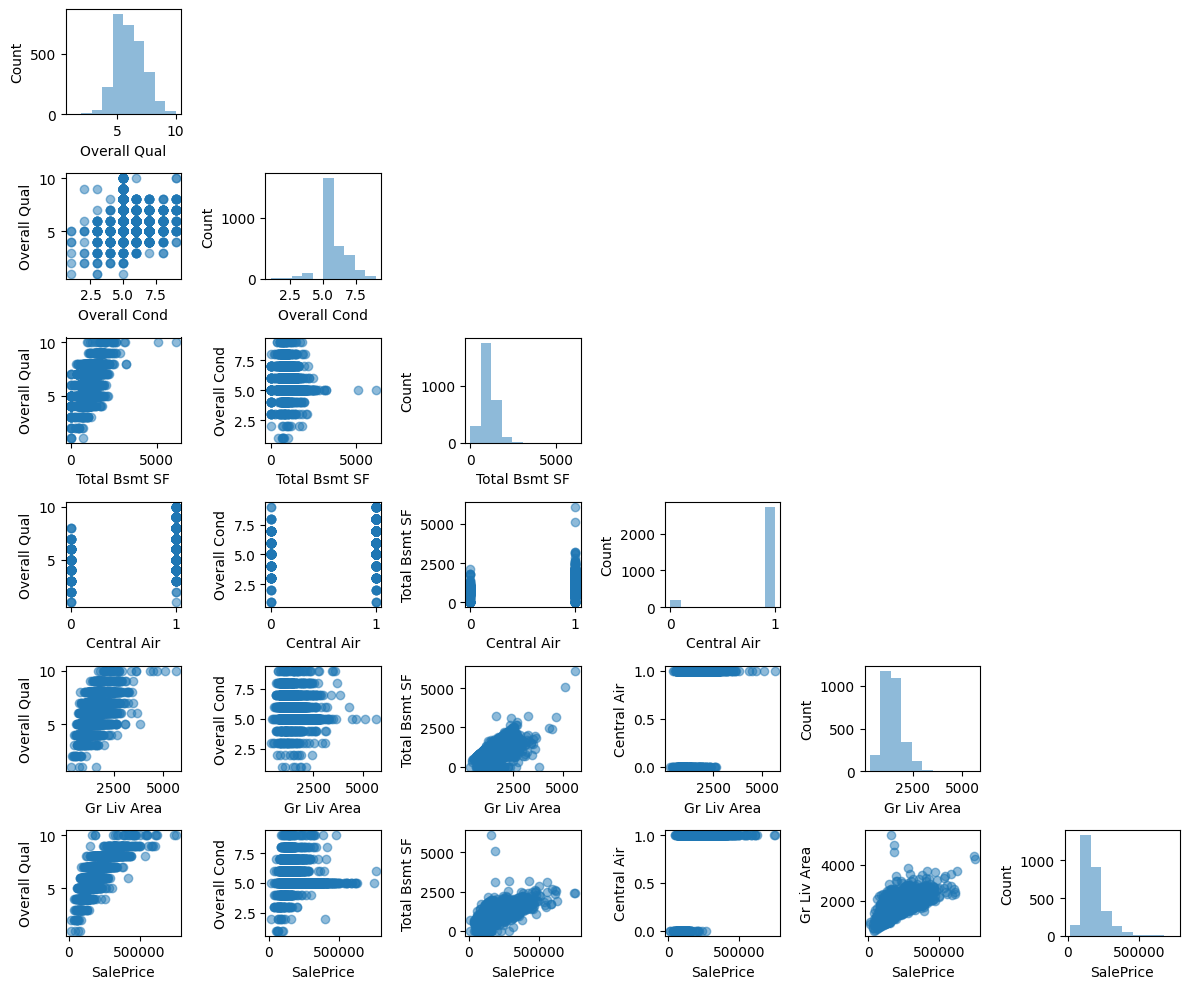

In [10]:
scatterplotmatrix(df.values, figsize=(12, 10), names=df.columns, alpha=0.5)
plt.tight_layout()
plt.show()

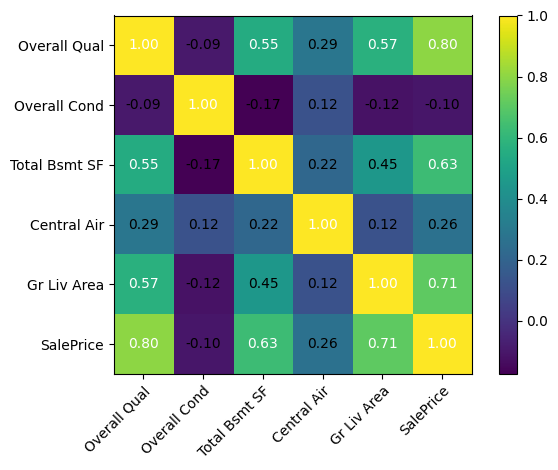

In [13]:
cm = np.corrcoef(df.values.T)
hm = heatmap(cm, row_names=df.columns, column_names=df.columns)
plt.tight_layout()
plt.show()

In [14]:
class LinearRegressionsGD:
    def __init__(self, eta=0.01, n_iter=50, random_state=1):
        self.eta = eta
        self.n_iter = n_iter
        self.random_state = random_state
    
    def fit(self,X, y):
        rgen = np.random.RandomState(self.random_state)
        self.w_ = rgen.normal(loc=0.0, scale=0.01, size=X.shape[1])
        self.b_ = np.array([0.])
        self.losses_ = []
        for i in range(self.n_iter):
            output = self.net_input(X)
            errors = (y - output)
            self.w_ += self.eta * 2.0 * X.T.dot(errors) / X.shape[0]
            self.b_ += self.eta * 2.0 * errors.mean()
            loss = (errors**2).mean()
            self.losses_.append(loss)
        return self
    def net_input(self, X):
        return np.dot(X, self.w_) + self.b_
    def predict(self, X):
        return self.net_input(X)

In [15]:
from sklearn.preprocessing import StandardScaler
X = df[['Gr Liv Area']].values
y = df['SalePrice'].values
sc_x = StandardScaler()
sc_y = StandardScaler()
X_std = sc_x.fit_transform(X)
y_std = sc_y.fit_transform(y[:, np.newaxis]).flatten()
lr = LinearRegressionsGD(eta=0.1)
lr.fit(X_std, y_std)

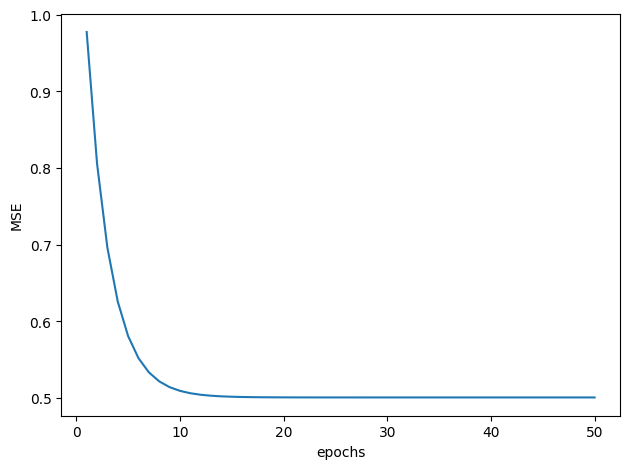

In [16]:
plt.plot(range(1, lr.n_iter + 1,), lr.losses_)
plt.ylabel('MSE')
plt.xlabel('epochs')
plt.tight_layout()
plt.show()

In [17]:
def line_reg(X, y, model):
    plt.scatter(X, y, c='steelblue', edgecolor='white', s=70)
    plt.plot(X, model.predict(X), color='black', lw=2)

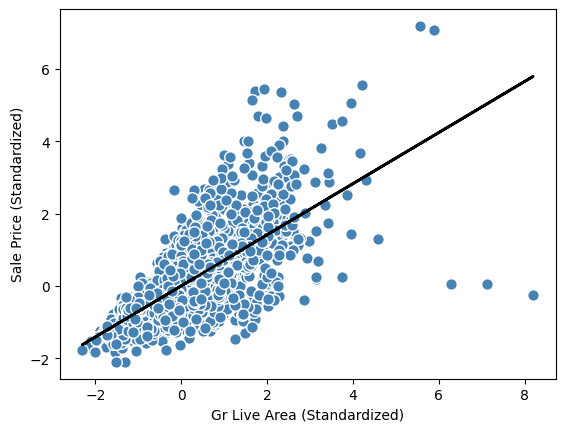

In [18]:
line_reg(X_std, y_std, lr)
plt.xlabel('Gr Live Area (Standardized)')
plt.ylabel('Sale Price (Standardized)')
plt.show()

In [19]:
feature_std = sc_x.transform(np.array([[2500]]))
target_std = lr.predict(feature_std)
targeted_reverse = sc_y.inverse_transform(target_std.reshape(-1, 1))
print(f'Sale Price: {targeted_reverse.flatten()[0]:0.2f}')

Sale Price: 292523.08


In [20]:
from sklearn.linear_model import LinearRegression
slr = LinearRegression()
slr.fit(X,y)
y_pred = slr.predict(X)
print(f'Slope: {slr.coef_[0]:0.3f}')
print(f'Intercept: {slr.intercept_:0.3f}')

Slope: 111.694
Intercept: 13289.634


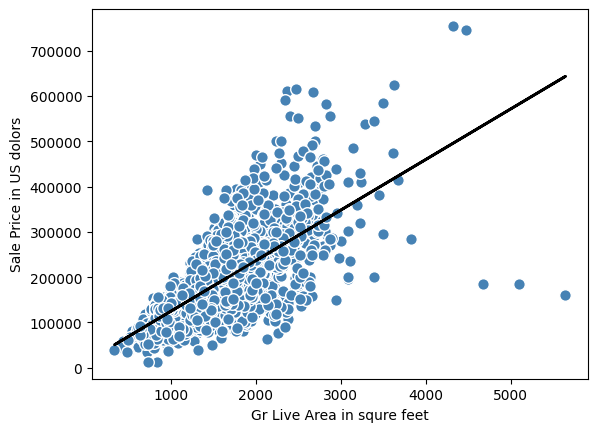

In [22]:
line_reg(X, y, slr)
plt.xlabel('Gr Live Area in squre feet')
plt.ylabel('Sale Price in US dolors')
plt.show()

In [23]:
from sklearn.linear_model import RANSACRegressor
ransac = RANSACRegressor(
    LinearRegression(),
    max_trials=100,
    min_samples=0.95,
    residual_threshold=None,
    random_state=123
)
ransac.fit(X, y)

,"estimator estimator: object, default=NoneBase estimator object which implements the following methods:* `fit(X, y)`: Fit model to given training data and target values.* `score(X, y)`: Returns the mean accuracy on the given test data, which is used for the stop criterion defined by `stop_score`. Additionally, the score is used to decide which of two equally large consensus sets is chosen as the better one.* `predict(X)`: Returns predicted values using the linear model, which is used to compute residual error using loss function.If `estimator` is None, then:class:`~sklearn.linear_model.LinearRegression` is used fortarget values of dtype float.Note that the current implementation only supports regressionestimators.",LinearRegression()
,"min_samples min_samples: int (>= 1) or float ([0, 1]), default=NoneMinimum number of samples chosen randomly from original data. Treatedas an absolute number of samples for `min_samples >= 1`, treated as arelative number `ceil(min_samples * X.shape[0])` for`min_samples < 1`. This is typically chosen as the minimal number ofsamples necessary to estimate the given `estimator`. By default a:class:`~sklearn.linear_model.LinearRegression` estimator is assumed and`min_samples` is chosen as ``X.shape[1] + 1``. This parameter is highlydependent upon the model, so if a `estimator` other than:class:`~sklearn.linear_model.LinearRegression` is used, the user mustprovide a value.",0.95
,"random_state random_state: int, RandomState instance, default=NoneThe generator used to initialize the centers.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",123
,"residual_threshold residual_threshold: float, default=NoneMaximum residual for a data sample to be classified as an inlier.By default the threshold is chosen as the MAD (median absolutedeviation) of the target values `y`. Points whose residuals arestrictly equal to the threshold are considered as inliers.",None
,"is_data_valid is_data_valid: callable, default=NoneThis function is called with the randomly selected data before themodel is fitted to it: `is_data_valid(X, y)`. If its return value isFalse the current randomly chosen sub-sample is skipped.",None
,"is_model_valid is_model_valid: callable, default=NoneThis function is called with the estimated model and the randomlyselected data: `is_model_valid(model, X, y)`. If its return value isFalse the current randomly chosen sub-sample is skipped.Rejecting samples with this function is computationally costlier thanwith `is_data_valid`. `is_model_valid` should therefore only be used ifthe estimated model is needed for making the rejection decision.",None
,"max_trials max_trials: int, default=100Maximum number of iterations for random sample selection.",100
,"max_skips max_skips: int, default=np.infMaximum number of iterations that can be skipped due to finding zeroinliers or invalid data defined by ``is_data_valid`` or invalid modelsdefined by ``is_model_valid``... versionadded:: 0.19",inf
,"stop_n_inliers stop_n_inliers: int, default=np.infStop iteration if at least this number of inliers are found.",inf
,"stop_score stop_score: float, default=np.infStop iteration if score is greater equal than this threshold.",inf
,"stop_probability stop_probability: float in range [0, 1], default=0.99RANSAC iteration stops if at least one outlier-free set of the trainingdata is sampled in RANSAC. This requires to generate at least Nsamples (iterations):: N >= log(1 - probability) / log(1 - e**m)where the probability (confidence) is typically set to high value suchas 0.99 (the default) and e is the current fraction of inliers w.r.t.the total number of samples.",0.99


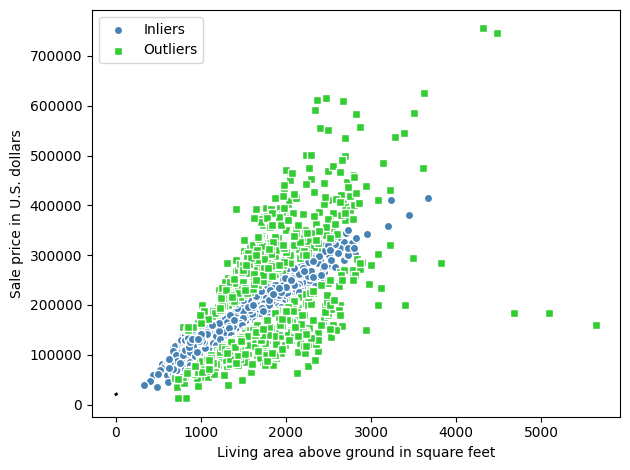

In [24]:
inlier = ransac.inlier_mask_
outlier = np.logical_not(inlier)
line_X = np.arange(3, 10, 1)
line_y = ransac.predict(line_X[:, np.newaxis])
plt.scatter(X[inlier], y[inlier], c='steelblue', edgecolor='white', marker='o', label='Inliers')
plt.scatter(X[outlier], y[outlier], c='limegreen', edgecolor='white', marker='s', label='Outliers')
plt.plot(line_X, line_y, color='black', lw=2)
plt.xlabel('Living area above ground in square feet')
plt.ylabel('Sale price in U.S. dollars')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

In [25]:
print(f'Slope: {ransac.estimator_.coef_[0]:0.3f}')
print(f'Intercept: {ransac.estimator_.intercept_:0.3f}')

Slope: 106.451
Intercept: 20133.205


In [ ]:
def MAD(data):
    return np.mean(np.abs(data - np.mean(data)))
MAD(y)

np.float64(58276.315729245536)

In [33]:
from sklearn.model_selection import train_test_split
target = 'SalePrice'
features = df.columns[df.columns != target]
X = df[features].values
y = df[target].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=123)
slr = LinearRegression()
slr.fit(X_train, y_train)
y_train_pred = slr.predict(X_train)
y_test_pred = slr.predict(X_test)

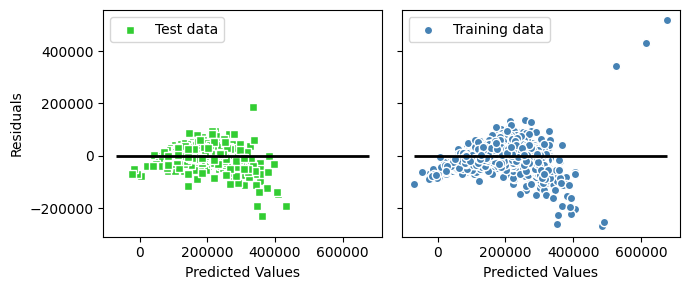

In [34]:
x_max = np.max([np.max(y_train_pred), np.max(y_test_pred)])
x_min = np.min([np.min(y_train_pred), np.min(y_test_pred)])
fig, (ax1, ax2) = plt.subplots(1, 2 , figsize=(7, 3), sharey=True)
ax1.scatter(y_test_pred, y_test_pred - y_test, c='limegreen', marker='s', edgecolor='white', label='Test data')
ax2.scatter(y_train_pred, y_train_pred - y_train, c='steelblue', marker='o', edgecolor='white', label='Training data')
ax1.set_ylabel('Residuals')

for ax in (ax1, ax2):
    ax.set_xlabel('Predicted Values')
    ax.legend(loc='upper left')
    ax.hlines(y=0, xmin=x_min - 100, xmax=x_max + 100, color='black', lw=2)
plt.tight_layout()
plt.show()

In [35]:
from sklearn.metrics import mean_squared_error
mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)
print(f'MSE train: {mse_train:.3f}')
print(f'MSE test: {mse_test:.3f}')

MSE train: 1625014901.924
MSE test: 1219439299.132


In [36]:
from sklearn.metrics import mean_absolute_error
mse_train = mean_absolute_error(y_train, y_train_pred)
mse_test = mean_absolute_error(y_test, y_test_pred)
print(f'MSE train: {mse_train:.3f}')
print(f'MSE test: {mse_test:.3f}')

MSE train: 26257.957
MSE test: 24901.362


In [37]:
from sklearn.metrics import r2_score
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
print(f'R^2 train: {train_r2:.3f}, {test_r2:.3f}')

R^2 train: 0.752, 0.796


In [38]:
from sklearn.preprocessing import PolynomialFeatures
X = np.array([258.0, 270.0, 294.0, 320.0, 342.0,
368.0, 396.0, 446.0, 480.0, 586.0])[:, np.newaxis]
y = np.array([236.4, 234.4, 252.8, 298.6, 314.2,
342.2, 360.8, 368.0, 391.2, 390.8])
lr = LinearRegression()
pr = LinearRegression()
poly = PolynomialFeatures(degree=2)
X_quad = poly.fit_transform(X)

In [39]:
lr.fit(X, y)
X_fit = np.arange(250, 600, 10)[:, np.newaxis]
y_lin_fit = lr.predict(X_fit)

In [41]:
pr.fit(X_quad, y)
y_quad_fit = pr.predict(poly.fit_transform(X_fit))

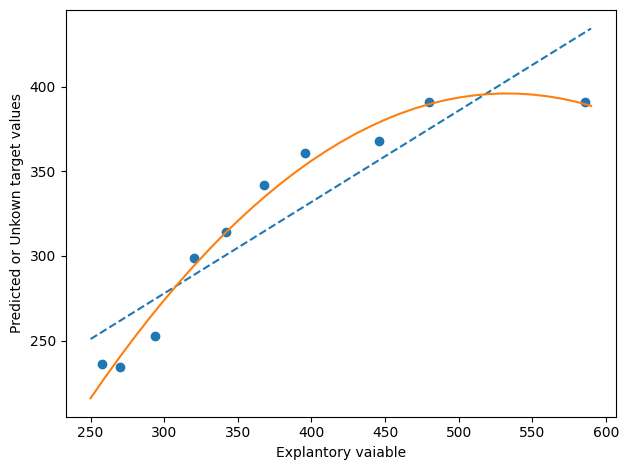

In [42]:
plt.scatter(X, y, label='Training points')
plt.plot(X_fit, y_lin_fit, linestyle='--', label='Linear Fit')
plt.plot(X_fit, y_quad_fit, label='Quadratic Fit')
plt.xlabel('Explantory vaiable')
plt.ylabel('Predicted or Unkown target values')
plt.tight_layout()
plt.show()

In [43]:
y_lin_pred = lr.predict(X)
y_quad_pred = pr.predict(X_quad)
mse_line = mean_squared_error(y, y_lin_pred)
mse_quad = mean_squared_error(y, y_quad_pred)
print(f'MSE liner: {mse_line:.3f}')
print(f'MSE Quad: {mse_quad:.3f}')
mse_line = r2_score(y, y_lin_pred)
mse_quad = r2_score(y, y_quad_pred)
print(f'R2 Score: {mse_line} / {mse_quad}')

MSE liner: 569.780
MSE Quad: 61.330
R2 Score: 0.8317053837891232 / 0.9818850241163604


In [44]:
X = df[['Gr Liv Area']].values
y = df['SalePrice'].values
X_inliers = X[(df['Gr Liv Area'] < 4000)]
y_liers = y[(df['Gr Liv Area'] < 4000)]

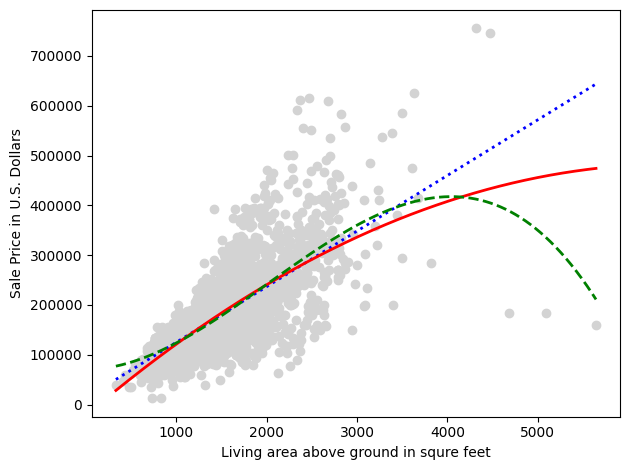

In [49]:
reger = LinearRegression()
quad = PolynomialFeatures(degree=2)
cubic = PolynomialFeatures(degree=3)
X_quad = quad.fit_transform(X)
X_cubic = cubic.fit_transform(X)
X_fit = np.arange(X.min() - 1, X.max() + 2, 1)[:, np.newaxis]
reger = reger.fit(X, y)
y_line_fit = reger.predict(X_fit)
linear_r2 = r2_score(y, reger.predict(X))
reger = reger.fit(X_quad, y)
y_quad_fit = reger.predict(quad.fit_transform(X_fit))
quad_r2 = r2_score(y, reger.predict(X_quad))
reger = reger.fit(X_cubic, y)
y_cubic_fit = reger.predict(cubic.fit_transform(X_fit))
cubic_r2 = r2_score(y, reger.predict(X_cubic))

# plot the results
plt.scatter(X, y, label='Training points', color='lightgray')
plt.plot(X_fit, y_line_fit, label=f'Linear (d=1): $R^2={linear_r2}', color='blue',lw=2, linestyle=':')
plt.plot(X_fit, y_quad_fit, label=f'Quad (d=2): $R^2={quad_r2}', color='red', lw=2, linestyle='-')
plt.plot(X_fit, y_cubic_fit, label=f'Cubic (d=3): $R^2={cubic_r2}', color='green', lw=2, linestyle='--')
plt.xlabel('Living area above ground in squre feet')
plt.ylabel('Sale Price in U.S. Dollars')
plt.tight_layout()
plt.show()


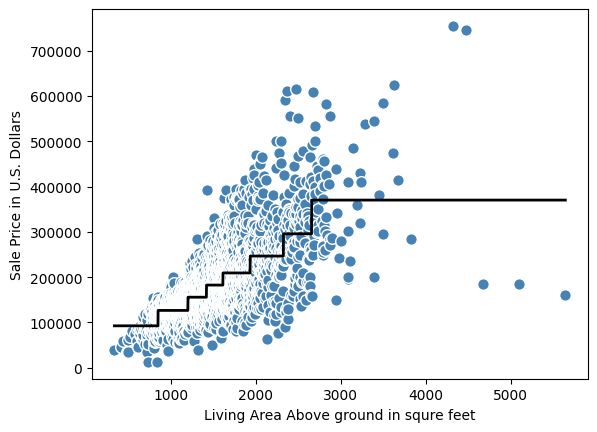

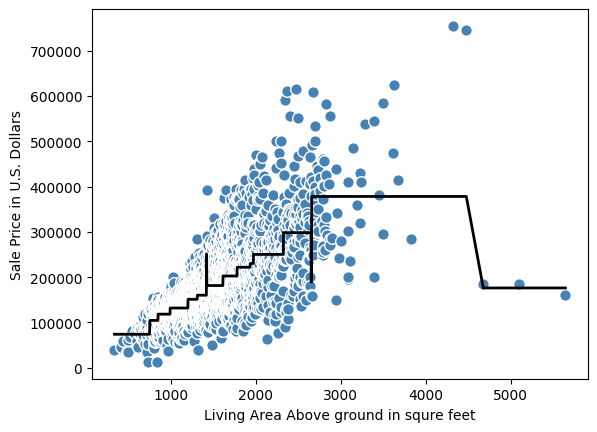

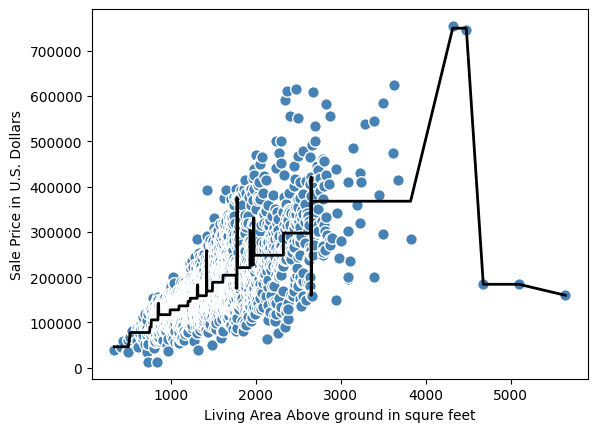

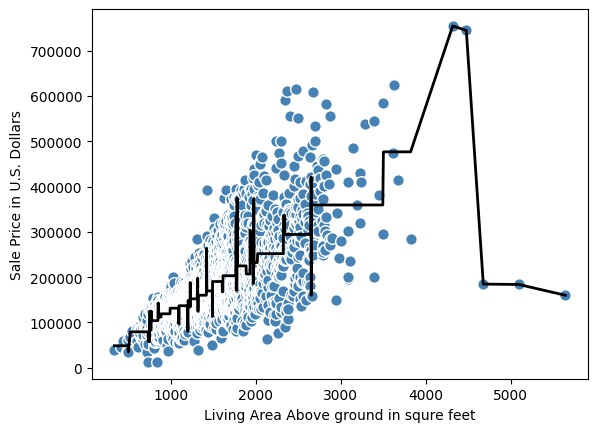

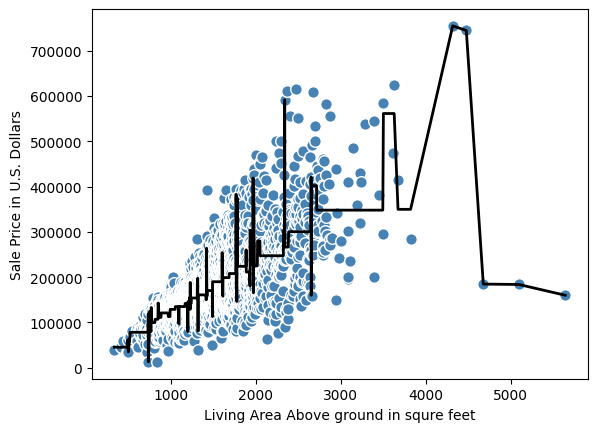

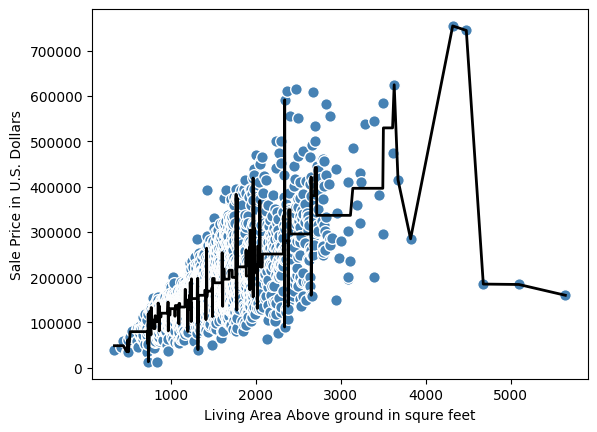

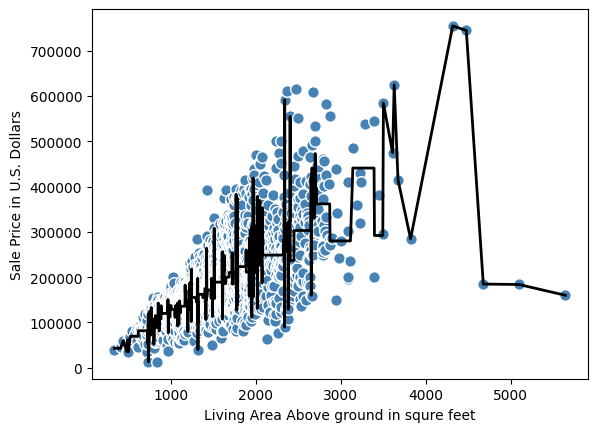

In [51]:
from sklearn.tree import DecisionTreeRegressor
X = df[['Gr Liv Area']].values
y = df['SalePrice'].values
for i in range(3, 10):
    tree = DecisionTreeRegressor(max_depth=i)
    tree.fit(X,y)
    sort_idx = X.flatten().argsort()
    line_reg(X[sort_idx], y[sort_idx], tree)
    plt.xlabel('Living Area Above ground in squre feet')
    plt.ylabel('Sale Price in U.S. Dollars')
    plt.show()

The trees is overfitting as we increase number of max_depth

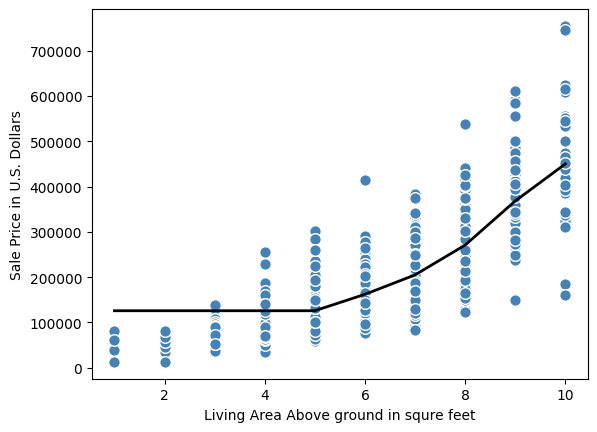

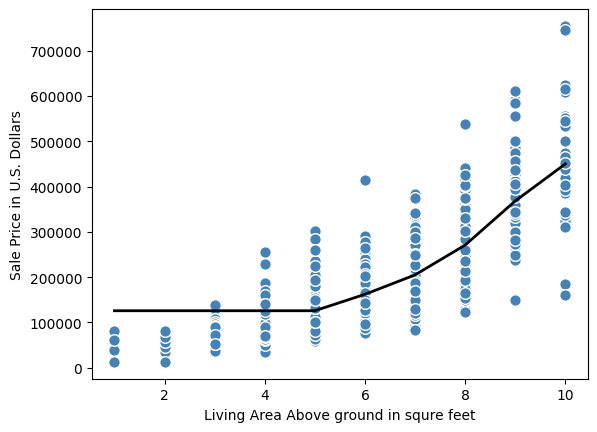

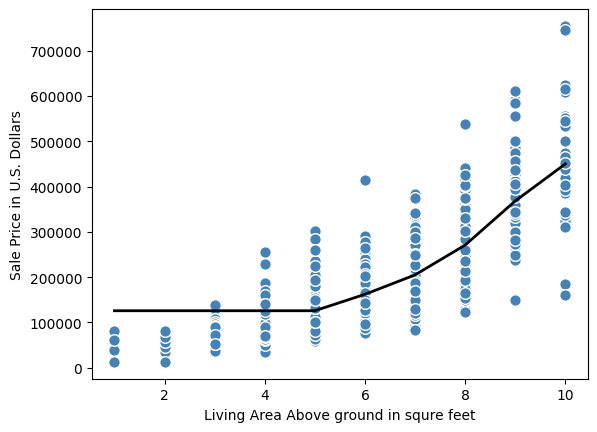

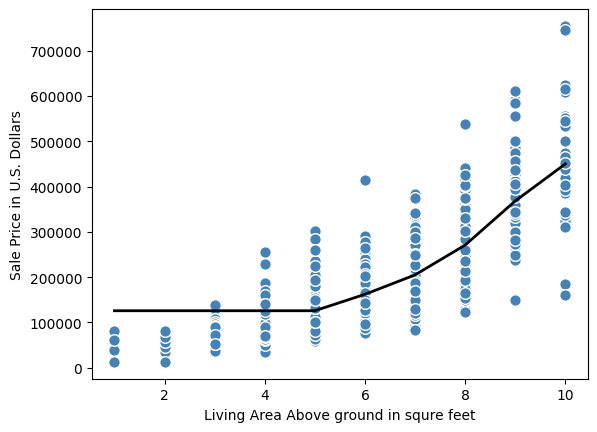

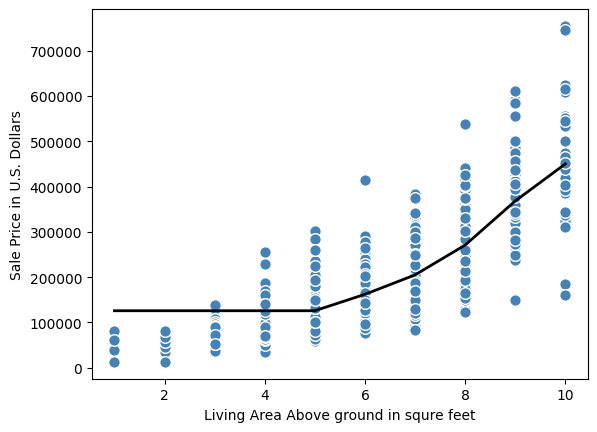

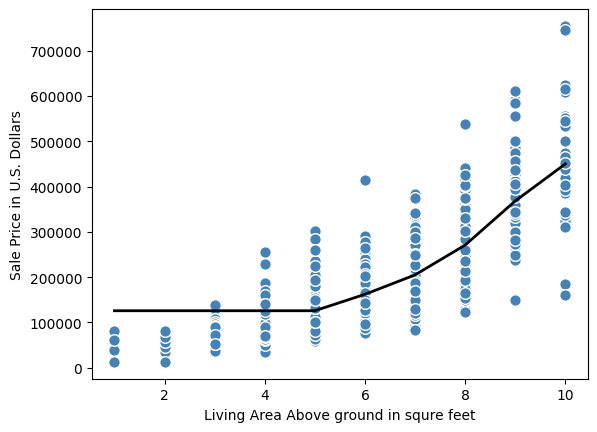

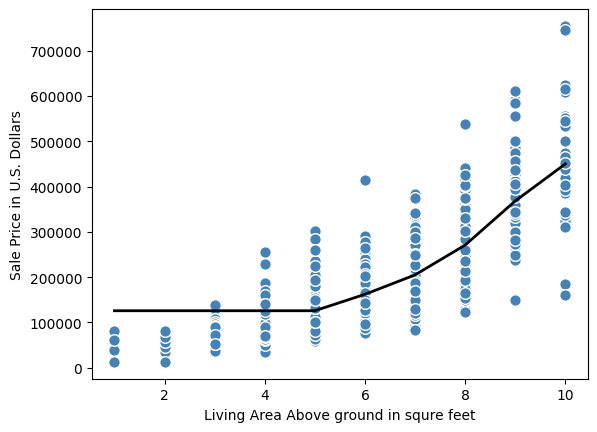

In [52]:
from sklearn.tree import DecisionTreeRegressor
for i in range(3, 10):
    X = df[['Overall Qual']].values
    y = df['SalePrice'].values
    tree = DecisionTreeRegressor(max_depth=3)
    tree.fit(X,y)
    sort_idx = X.flatten().argsort()
    line_reg(X[sort_idx], y[sort_idx], tree)
    plt.xlabel('Living Area Above ground in squre feet')
    plt.ylabel('Sale Price in U.S. Dollars')
    plt.show()

again our trees is overfitting the data as max_depth is increasing

In [54]:
from sklearn.ensemble import RandomForestRegressor
target = 'SalePrice'
features = df.columns[df.columns != target]
X = df[features].values
y = df[target].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=123)

forest = RandomForestRegressor(
    n_estimators=500,
    criterion='squared_error',
    random_state=1,
    n_jobs=None # make it = -1 if you want to use all of your cpu cores
)
forest.fit(X_train, y_train)
y_train_pred = forest.predict(X_train)
y_test_pred = forest.predict(X_test)
mae_train = mean_absolute_error(y_train, y_train_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)
print(f'MAE train: {mae_train:.3f}')
print(f'MAE test: {mae_test:.3f}')
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)
print(f'R^2 train: {r2_train:.3f}')
print(f'R^2 test: {r2_test:.3f}')

MAE train: 8368.859
MAE test: 21491.427
R^2 train: 0.976
R^2 test: 0.834


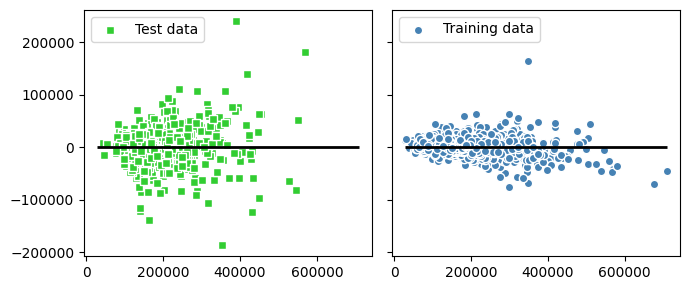

In [55]:
x_max = np.max([np.max(y_train_pred), np.max(y_test_pred)])
x_min = np.min([np.min(y_train_pred), np.min(y_test_pred)])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7, 3), sharey=True)
ax1.scatter(y_test_pred, y_test_pred - y_test, c='limegreen', marker='s', edgecolor='white', label='Test data')
ax2.scatter(y_train_pred, y_train_pred - y_train, c='steelblue', marker='o', edgecolor='white', label='Training data')

for ax in (ax1, ax2):
    ax.set_label('Predicted Values')
    ax.legend(loc='upper left')
    ax.hlines(y=0, xmin=x_min - 100, xmax=x_max+100, color='black', lw=2)
plt.tight_layout()
plt.show()